In [1]:
import sys
sys.path.append("..")

from src.config import EPOCHS
from src.data_loader import get_dataframes
from src.preprocess import make_dataset
from src.train import build_model, compile_model, train_model

In [2]:
train_df, val_df = get_dataframes()

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)

In [3]:
model = build_model()
model = compile_model(model)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 29)             │        37,149 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,295,133 (8.76 MB)

 Trainable params: 37,149 (145.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [4]:
history = train_model(
    model=model,
    train_ds=train_ds,
    val_ds=val_ds,
    epochs=2
)

Epoch 1/2
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.7634 - loss: 0.9176
Epoch 1: val_loss improved from None to 0.09579, saving model to D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\models\best_model.keras

Epoch 1: finished saving model to D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\models\best_model.keras
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 708s 324ms/step - accuracy: 0.8898 - loss: 0.4313 - val_accuracy: 0.9816 - val_loss: 0.0958 - learning_rate: 0.0010
Epoch 2/2
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9641 - loss: 0.1323
Epoch 2: val_loss improved from 0.09579 to 0.04679, saving model to D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\models\best_model.keras

Epoch 2: finished saving model to D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\models\best_model.keras
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 707s 325ms/step - accuracy: 0.9663 - loss: 0.1194 - val_accuracy: 0.9908 - val_loss: 0.0468 - learning_rate: 0.0010


In [11]:
history = train_model(
    model=model,
    train_ds=train_ds,
    val_ds=val_ds,
    epochs=3
)

Epoch 1/3
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.9724 - loss: 0.0901
Epoch 1: val_loss improved from None to 0.03346, saving model to D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\models\best_model.keras

Epoch 1: finished saving model to D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\models\best_model.keras
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1295s 595ms/step - accuracy: 0.9734 - loss: 0.0863 - val_accuracy: 0.9933 - val_loss: 0.0335 - learning_rate: 0.0010
Epoch 2/3
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.9763 - loss: 0.0755
Epoch 2: val_loss improved from 0.03346 to 0.02710, saving model to D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\models\best_model.keras

Epoch 2: finished saving model to D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\models\best_model.keras
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 930s 428ms/step - accuracy: 0.9771 - loss: 0.0730 - val_accuracy: 0.9928 - val_loss: 0.0271 - learning_rate: 0.0010
Epoch 3/3
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - acc

In [17]:
from src.evaluate import plot_training_history, show_classification_report, plot_confusion_matrix

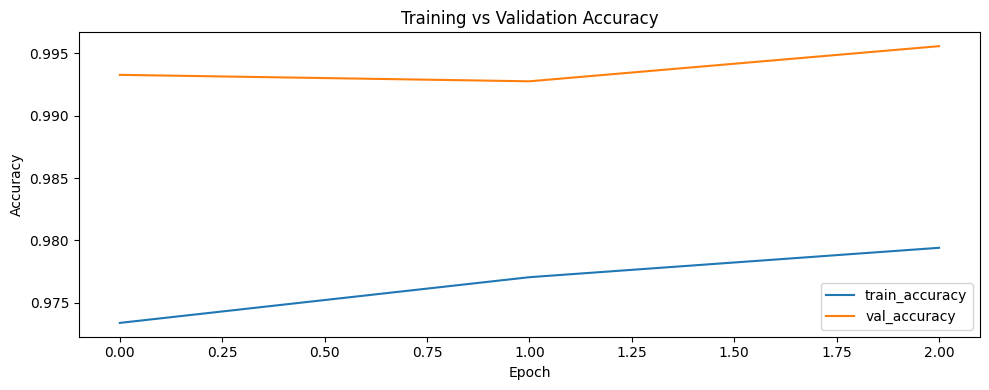

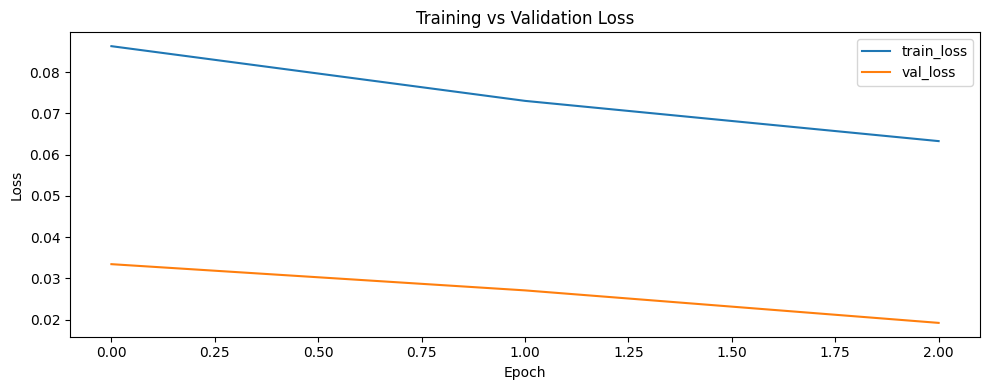

In [13]:
plot_training_history(history)

In [14]:
y_true, y_pred = show_classification_report(model, val_ds)

              precision    recall  f1-score   support

           A     0.9983    1.0000    0.9992       600
           B     0.9983    1.0000    0.9992       600
           C     1.0000    0.9950    0.9975       600
           D     0.9983    1.0000    0.9992       600
           E     0.9933    0.9917    0.9925       600
           F     1.0000    1.0000    1.0000       600
           G     0.9950    1.0000    0.9975       600
           H     1.0000    0.9967    0.9983       600
           I     0.9917    0.9950    0.9933       600
           J     0.9983    1.0000    0.9992       600
           K     0.9967    0.9967    0.9967       600
           L     1.0000    1.0000    1.0000       600
           M     0.9950    0.9983    0.9967       600
           N     0.9983    0.9933    0.9958       600
           O     0.9983    0.9983    0.9983       600
           P     1.0000    0.9800    0.9899       600
           Q     0.9885    1.0000    0.9942       600
           R     0.9933    

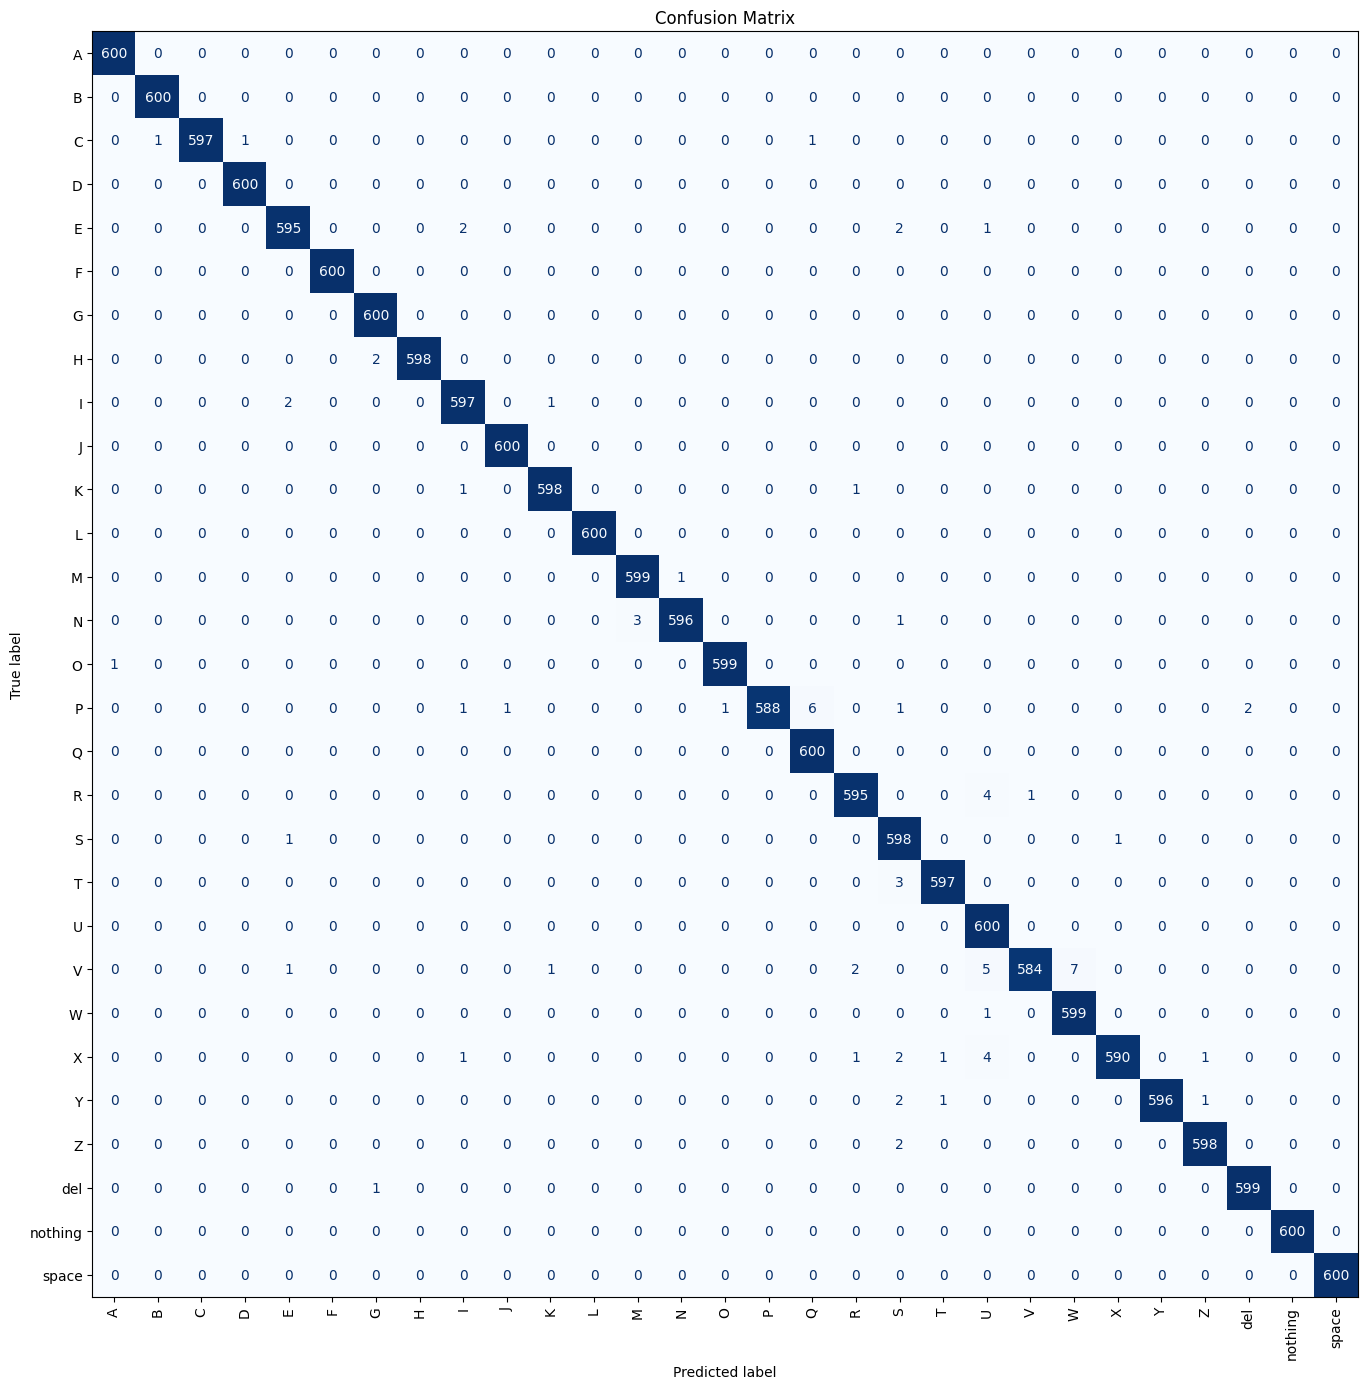

In [15]:
cm = plot_confusion_matrix(model, val_ds)

In [16]:
from src.config import LABEL_MAP_PATH, CLASS_NAMES
from src.utils import save_json

label_map = {str(i): label for i, label in enumerate(CLASS_NAMES)}
save_json(label_map, LABEL_MAP_PATH)

print("Label map saved to:", LABEL_MAP_PATH)

Label map saved to: D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\models\label_map.json
